# Analyse des Couleurs  
Ce notebook explore les couleurs dominantes de chaque image.
Nous utilisons l'histogramme RGB et l'extraction de couleurs dominantes via K-Means clustering.

## Extraction des Couleurs  
Nous utilisons un algorithme de clustering (K-Means) pour détecter les couleurs dominantes dans chaque image.

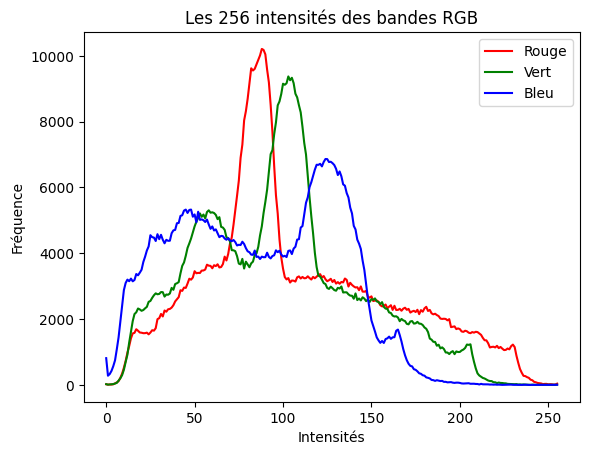

In [2]:
from PIL import Image
import matplotlib.pyplot as plt
import os

IMG_FOLDER = "../data_collection/images"
IMG_PATH = os.path.join(IMG_FOLDER, "Asmara2.jpg")
imgfile = Image.open(IMG_PATH)

histogram = imgfile.histogram()

red = histogram[0:256]
green = histogram[256:512]
blue = histogram[512:768]

x = range(256)
red_intensities = red[:256]
green_intensities = green[:256]
blue_intensities = blue[:256]

plt.plot(x, red_intensities, color="red", label="Rouge")
plt.plot(x, green_intensities, color="green", label="Vert")
plt.plot(x, blue_intensities, color="blue", label="Bleu")

# Ajouter des légendes et afficher le graphique
plt.title("Les 256 intensités des bandes RGB")
plt.xlabel("Intensités")
plt.ylabel("Fréquence")
plt.legend()
plt.show()


In [7]:
import json
from PIL import Image, ExifTags
import os
import cv2
import numpy as np
from sklearn.cluster import KMeans

IMAGE_FOLDER = "../data_collection/images"
ANNOTATION_FILE = "annotations.json"

def convert_to_serializable(obj):
    """ Convertit les objets IFDRational en float/int pour JSON """
    if isinstance(obj, tuple):
        return tuple(convert_to_serializable(x) for x in obj)
    if isinstance(obj, list):
        return [convert_to_serializable(x) for x in obj]
    if isinstance(obj, dict):
        return {key: convert_to_serializable(value) for key, value in obj.items()}
    if isinstance(obj, (int, float, str)) or obj is None:
        return obj
    try:
        return float(obj)  # Convertir les IFDRational en float
    except (TypeError, ValueError):
        return str(obj)  # Convertir les objets inconnus en string

def get_exif_data(image):
    """ Récupère les métadonnées EXIF d'une image """
    try:
        exif_data = image._getexif()
        if not exif_data:
            return {}
        return {ExifTags.TAGS.get(tag, tag): convert_to_serializable(value) for tag, value in exif_data.items()}
    except AttributeError:
        return {}

def get_gps_info(exif_data):
    """ Extrait les informations GPS si elles existent """
    if "GPSInfo" not in exif_data:
        return None
    
    gps_info = exif_data["GPSInfo"]
    
    if 2 not in gps_info or 4 not in gps_info:
        return None
    
    try:
        lat = [float(x) / float(y) if isinstance(x, tuple) else float(x) for x in gps_info[2]]
        lon = [float(x) / float(y) if isinstance(x, tuple) else float(x) for x in gps_info[4]]

        latitude = lat[0] + (lat[1] / 60.0) + (lat[2] / 3600.0)
        longitude = lon[0] + (lon[1] / 60.0) + (lon[2] / 3600.0)

        if gps_info[1] == 'S': latitude = -latitude
        if gps_info[3] == 'W': longitude = -longitude

        return {"latitude": latitude, "longitude": longitude}
    
    except Exception as e:
        print(f"Erreur lors de l'extraction des données GPS : {e}")
        return None

def get_dominant_colors(image_path, num_colors=3):
    pixels = cv2.resize(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB), (200, 200)).reshape(-1, 3)
    return ["#{:02x}{:02x}{:02x}".format(*map(int, color)) for color in KMeans(n_clusters=num_colors, random_state=42).fit(pixels).cluster_centers_]

def get_image_metadata(image_path):
    with Image.open(image_path) as img:
        exif_data = get_exif_data(img)
        gps_info = get_gps_info(exif_data)

        metadata = {
            "format": img.format,
            "size": img.size,
            "mode": img.mode,
            "device": exif_data.get("Make", "Unknown") + " " + exif_data.get("Model", "Unknown"),
            "capture_date": exif_data.get("DateTimeOriginal", "Unknown"),
            "iso": exif_data.get("ISOSpeedRatings", "Unknown"),
            "focal_length": exif_data.get("FocalLength", "Unknown"),
            "exposure_time": exif_data.get("ExposureTime", "Unknown"),
            "gps": gps_info if gps_info else "No GPS Data"
        }
        
        return metadata

def process_images():
    annotations = {
        f: {
            "dominant_colors": get_dominant_colors(os.path.join(IMAGE_FOLDER, f)),
            "metadata": get_image_metadata(os.path.join(IMAGE_FOLDER, f))
        } 
        for f in os.listdir(IMAGE_FOLDER) if f.endswith((".jpg", ".jpeg", ".png"))
    }
    with open(ANNOTATION_FILE, "w") as f:
        json.dump(annotations, f, indent=4, default=convert_to_serializable)

if __name__ == "__main__":
    process_images()
